In [24]:
import numpy as np
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler, StandardScaler

def adf_test(series, title=""):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f"Augmented Dickey-Fuller Test: {title}")
    result = adfuller(
        series.dropna(), autolag="AIC"
    )  # .dropna() handles differenced data

    labels = ["ADF test statistic", "p-value", "# lags used", "# observations"]
    out = pd.Series(result[0:4], index=labels)

    for key, val in result[4].items():
        out[f"critical value ({key})"] = val

    print(out.to_string())  # .to_string() removes the line "dtype: float64"

    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

def total_mean_error(predictions):
    mean_error = []

    for i in range(len(predictions)):
        if df['Normalized'][i] == 0:
            error_value = np.abs((predictions[i]-0.01)/(0.01))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df['Normalized'][i]}, erro={error_value}%"
            )
        else:
            error_value = np.abs((predictions[i]-df['Normalized'][i])/(df['Normalized'][i]))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df['Normalized'][i]}, erro={error_value}%"
            )

    aux = 0

    for i in range(len(mean_error)):
        if mean_error[i] > 200:
            aux = aux
        else:
            aux = mean_error[i] + aux

    final_mean = aux/len(mean_error)

    print(f"Erro percentual médio = {final_mean}%")

In [25]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"
df

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


In [26]:
df = pd.concat([df, df])
with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.precision",
    3,
):
    print(df)

           3003858507 3001084033 3011373971 3001449459 3011504476
idx                                                              
2019-06-01     1246.0     7160.0      440.0      960.0     1560.0
2019-07-01     1081.0     6520.0      600.0      920.0     1280.0
2019-08-01     1184.0     6840.0      680.0     1120.0     1360.0
2019-09-01     1549.0     7440.0      760.0     1040.0     1680.0
2019-10-01     2045.0     6920.0      560.0     1120.0     1680.0
2019-11-01     4017.0     6920.0      520.0     1240.0     2920.0
2019-12-01     2386.0     7240.0      320.0     1000.0     1960.0
2020-01-01     4239.0     6560.0      440.0     1120.0     2280.0
2020-02-01     2854.0     7440.0      280.0     1200.0     2480.0
2020-03-01     3208.0     7440.0      320.0     1360.0     2240.0
2020-04-01     1048.0     5640.0      440.0     1080.0     1480.0
2020-05-01     1313.0     4880.0        0.0     1040.0     1280.0
2020-06-01     1174.0     5080.0        0.0     1320.0     1240.0
2020-07-01

In [27]:
new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")

df.index = new_index

df

,3003858507,3001084033,3011373971,3001449459,3011504476
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
...,...,...,...,...,...
2026-07-01,1216.0,7440.0,920.0,1000.0,2280.0
2026-08-01,1335.0,7240.0,360.0,840.0,2000.0
2026-09-01,1317.0,7960.0,680.0,880.0,2160.0
2026-10-01,2367.0,5880.0,800.0,840.0,2120.0


In [28]:
values = df[3003858507].values
values = values.reshape((len(values), 1))

scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(values)

df_normalized = scaler.transform(values)
for i in range(5):
    print(df_normalized[i])

[0.17729522]
[0.13194063]
[0.16025289]
[0.26058274]
[0.39692139]


In [29]:
df["Normalized"] = df_normalized

In [30]:
auto_arima(
    df["Normalized"],
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   90
Model:             SARIMAX(3, 0, 1)x(0, 0, 1, 12)   Log Likelihood                  14.041
Date:                            Thu, 14 Mar 2024   AIC                            -14.081
Time:                                    14:07:35   BIC                              3.417
Sample:                                06-01-2019   HQIC                            -7.025
                                     - 11-01-2026                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0785      0.021      3.698      0.000       0.037       0.120
ar.L1          1.3881      0.103     13.501      0.000       1.187       1.590
ar.L2         -0.3264      0.167     -1.951      0.051      -0.654       0.002
ar.L3         -0.2433      0.111     -2.191      0.028      -0.461      -0.026
ma.L1         -0.9636      0.079    -12.255      0.000      -1.118      -0.810
ma.S.L12       0.0616      0.187      0.329      0.742      -0.305       0.428
sigma2         0.0412      0.007      5.725      0.000       0.027       0.055
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.60
Prob(Q):                              0.99   Prob(JB):                         0.45
Heteroskedasticity (H):               0.80   Skew:                             0.32
Prob(H) (two-sided):                  0.55   Kurtosis:                         3.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [31]:
train = df.iloc[:80]
test = df.iloc[80:]

test = test.astype(float)
train = train.astype(float)

model = SARIMAX(train["Normalized"], order=(3, 0, 1), seasonal_order=(5, 1, 1, 12))
results = model.fit()

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.10095D-01    |proj g|=  2.70684D-01

At iterate    5    f=  8.71145D-02    |proj g|=  3.85844D-02

At iterate   10    f=  8.06922D-02    |proj g|=  1.63841D-02

At iterate   15    f=  7.18141D-02    |proj g|=  4.69970D-02

At iterate   20    f=  5.67573D-02    |proj g|=  1.40892D-01

At iterate   25    f=  5.49325D-02    |proj g|=  1.89976D-02

At iterate   30    f=  5.30084D-02    |proj g|=  1.73301D-02

At iterate   35    f=  5.22312D-02    |proj g|=  9.75859D-03

At iterate   40    f=  5.07420D-02    |proj g|=  6.46134D-03

At iterate   45    f=  5.00961D-02    |proj g|=  6.94003D-03

At iterate   50    f=  4.97246D-02    |proj g|=  4.41128D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

In [32]:
start = len(train)
end = len(train) + len(test) - 1
normalized_predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

normalized_future_predictions = results.predict(
    start=end, end=end + 44, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

total_mean_error(normalized_predictions)

predição=0.0, esperado=0.1772952171522815, erro=100.0%
predição=1.9855831344192306e-08, esperado=0.13194062671797693, erro=99.99998495093449%
predição=2.9895017216443136e-08, esperado=0.16025288620120945, erro=99.99998134509903%
predição=3.6146087307008914e-08, esperado=0.26058273776800445, erro=99.99998612874836%
predição=4.864695366551961e-08, esperado=0.3969213853765806, erro=99.99998774393231%
predição=6.835653402002829e-08, esperado=0.9389774601429358, erro=99.99999272010918%
predição=1.3680765686102078e-07, esperado=0.49065420560747663, erro=99.9999721172966%
predição=1.2806792062442383e-07, esperado=1.0, erro=99.99998719320794%
predição=1.537757820175937e-07, esperado=0.6192963166575042, erro=99.9999751692723%
predição=1.1748563293600922e-07, esperado=0.7166025288620121, erro=99.99998360518862%
predição=7.24703790528276e-08, esperado=0.12286970863111599, erro=99.99994101851476%
predição=-4.164230521233037e-08, esperado=0.19571192963166575, erro=100.00002127734639%
predição=0.177

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

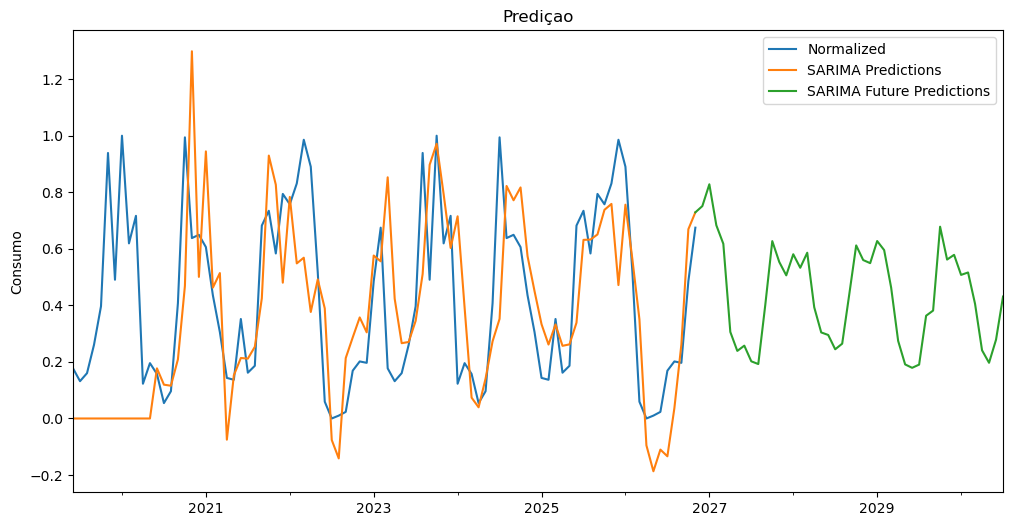

In [33]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df["Normalized"].plot(legend=True, figsize=(12, 6), title=title)
normalized_predictions.plot(legend=True)
normalized_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [34]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"

df = pd.concat([df, df])

new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")

df.index = new_index

df

,3003858507,3001084033,3011373971,3001449459,3011504476
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
...,...,...,...,...,...
2026-07-01,1216.0,7440.0,920.0,1000.0,2280.0
2026-08-01,1335.0,7240.0,360.0,840.0,2000.0
2026-09-01,1317.0,7960.0,680.0,880.0,2160.0
2026-10-01,2367.0,5880.0,800.0,840.0,2120.0


In [35]:
values = df[3001084033].values
values = values.reshape((len(values), 1))

scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(values)

df_normalized = scaler.transform(values)

df["Normalized"] = df_normalized

In [36]:
auto_arima(
    df["Normalized"],
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   90
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  24.986
Date:                Thu, 14 Mar 2024   AIC                            -43.972
Time:                        14:07:42   BIC                            -36.472
Sample:                    06-01-2019   HQIC                           -40.947
                         - 11-01-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2676      0.056      4.781      0.000       0.158       0.377
ar.L1          0.5682      0.091      6.229      0.000       0.389       0.747
sigma2         0.0335      0.005      6.984      0.000       0.024       0.043
===================================================================================
Ljung-Box (L1) (Q):                   0.39   Jarque-Bera (JB):                 2.00
Prob(Q):                              0.53   Prob(JB):                         0.37
Heteroskedasticity (H):               1.05   Skew:                            -0.33
Prob(H) (two-sided):                  0.89   Kurtosis:                         3.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [64]:
train = df.iloc[:80]
test = df.iloc[80:]

test = test.astype(float)
train = train.astype(float)

model = SARIMAX(train["Normalized"], order=(3, 1, 1), seasonal_order=(5, 1, 1, 12))
results = model.fit()

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -2.17109D-02    |proj g|=  6.81853D-01

At iterate    5    f= -1.09265D-01    |proj g|=  3.00209D-01

At iterate   10    f= -1.24587D-01    |proj g|=  4.57840D-01

At iterate   15    f= -1.34794D-01    |proj g|=  1.66563D-01

At iterate   20    f= -1.44975D-01    |proj g|=  1.92256D-01

At iterate   25    f= -1.65869D-01    |proj g|=  5.22036D-01

At iterate   30    f= -1.76922D-01    |proj g|=  5.50119D-02

At iterate   35    f= -1.85723D-01    |proj g|=  2.67986D-02

At iterate   40    f= -1.86365D-01    |proj g|=  2.87513D-02

At iterate   45    f= -1.89136D-01    |proj g|=  2.91913D-02

At iterate   50    f= -1.89316D-01    |proj g|=  5.04165D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

In [67]:
start = len(train)
end = len(train) + len(test) - 1
normalized_predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

normalized_future_predictions = results.predict(
    start=end, end=end + 88, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

total_mean_error(normalized_predictions)

predição=0.0, esperado=0.8095238095238094, erro=100.0%
predição=0.8095238027122051, esperado=0.6571428571428571, erro=23.18840476055296%
predição=0.657142861681802, esperado=0.7333333333333333, erro=10.389609770663354%
predição=0.733333323463812, esperado=0.8761904761904761, erro=16.30434895249971%
predição=0.8761904748556018, esperado=0.7523809523809523, erro=16.455696025111642%
predição=0.7523809519624763, esperado=0.7523809523809523, erro=5.5620217292644044e-08%
predição=0.7523809498518301, esperado=0.8285714285714286, erro=9.195402604089473%
predição=0.8285714296360441, esperado=0.6666666666666666, erro=24.285714445406626%
predição=0.6666666706991922, esperado=0.8761904761904761, erro=23.913043018026972%
predição=0.8761904742264642, esperado=0.8761904761904761, erro=2.241535254511656e-07%
predição=0.8761904788059227, esperado=0.44761904761904747, erro=95.74468143536578%
predição=0.4476190547237391, esperado=0.2666666666666667, erro=67.85714552140213%
predição=0.6714285760651725, es

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

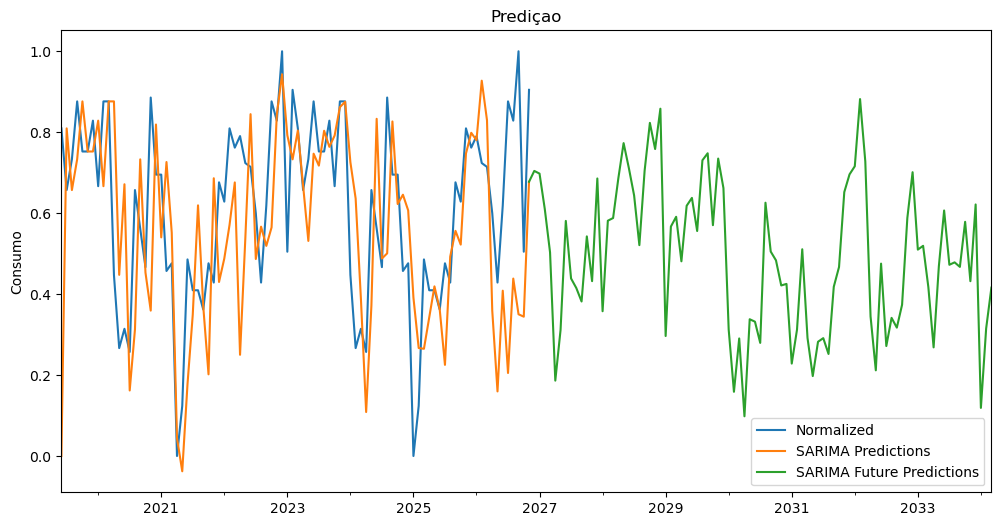

In [68]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df["Normalized"].plot(legend=True, figsize=(12, 6), title=title)
normalized_predictions.plot(legend=True)
normalized_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)